# H1 — Causas Comportamentais, Período Noturno e Gravidade

**Hipótese:** Causas comportamentais (ingestão de álcool, uso de substâncias psicoativas e sono ao volante) ocorrem com maior frequência no período noturno e estão associadas a maior gravidade do sinistro em comparação com outras causas no mesmo horário.

**Decomposição:**
- H1a: causas comportamentais são proporcionalmente mais frequentes na madrugada/noite?
- H1b: no período noturno, a chance de desfecho fatal é maior para causas comportamentais do que para outras causas?


In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
from pathlib import Path

from prf_sdk.analysis.hypotheses.h1 import verify_h1, BEHAVIORAL_CAUSES, NIGHT_PERIODS

In [2]:
BASE_DIR = Path(__name__).resolve().parent.parent

In [3]:
df = pd.read_csv(BASE_DIR / "data/processed/datatran_2022_2026_processed_v1.csv", index_col=0, low_memory=False)

pd.set_option("display.max_columns", None)
df.head()

,dia_semana,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_meteorologica,tipo_pista,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,data_hora,tr_em_obras,tr_aclive,tr_retorno_regulamentado,tr_viaduto,tr_curva,tr_intersecao_de_vias,tr_reta,tr_tunel,tr_desvio_temporario,tr_rotatoria,tr_ponte,tr_declive,n_caracteristicas_tracado,causa_acidente_grupo,feriado_nacional,estacao,regiao,mes,horario,faixa_km,fim_de_semana
1,sábado,PR,116,33.0,CAMPINA GRANDE DO SUL,Ingestão de álcool pelo condutor,Tombamento,Com Vítimas Fatais,Pleno dia,Decrescente,Nublado,Dupla,Não,3,1,1,0,0,1,1,2,-25.114403,-48.846755,2022-01-01 02:40:00,0,0,0,0,1,0,0,0,0,0,0,0,1,infracao_comportamento_risco,1,Verão,Sul,1,Madrugada,30.0,1
2,sábado,MS,163,393.0,NOVA ALVORADA DO SUL,Condutor deixou de manter distância do veículo...,Colisão traseira,Com Vítimas Feridas,Amanhecer,Decrescente,Céu Claro,Simples,Não,3,0,1,0,1,1,1,3,-21.228445,-54.456296,2022-01-01 05:22:00,0,1,0,0,0,0,0,0,0,0,0,0,1,falha_atencao_reacao,1,Verão,Centro-Oeste,1,Madrugada,390.0,1
3,sábado,RJ,101,457.0,ANGRA DOS REIS,Reação tardia ou ineficiente do condutor,Colisão frontal,Com Vítimas Feridas,Pleno dia,Decrescente,Chuva,Simples,Sim,2,0,0,1,1,0,1,2,-23.031498,-44.177153,2022-01-01 07:00:00,0,0,0,0,1,0,0,0,0,0,0,0,1,falha_atencao_reacao,1,Verão,Sudeste,1,Manhã,455.0,1
4,sábado,MG,40,508.3,RIBEIRAO DAS NEVES,Acumulo de água sobre o pavimento,Saída de leito carroçável,Sem Vítimas,Pleno dia,Decrescente,Chuva,Dupla,Sim,3,0,0,0,3,0,0,1,-19.760612,-44.134754,2022-01-01 09:00:00,0,0,0,0,0,0,1,0,0,0,0,0,1,condicao_ambiental,1,Verão,Sudeste,1,Manhã,505.0,1
5,sábado,PB,116,8.7,CACHOEIRA DOS INDIOS,Mal súbito do condutor,Colisão com objeto,Sem Vítimas,Pleno dia,Crescente,Céu Claro,Simples,Não,3,0,0,0,2,1,0,2,-6.964668,-38.727608,2022-01-01 09:00:00,0,0,0,0,0,0,1,0,0,0,0,0,1,condicao_saude_condutor,1,Verão,Nordeste,1,Manhã,5.0,1


## 1. Carregamento e verificação

In [4]:
#COMPORTAMENTAIS = ['infracao_comportamento_risco', 'falha_atencao_reacao']
result = verify_h1(df)
print(result.summary)

H1 — PARCIALMENTE CONFIRMADA

Causas comportamentais: 'Condutor Dormindo', 'Velocidade Incompatível', 'Ingestão de álcool pelo condutor', 'Ingestão de substâncias psicoativas pelo condutor'
(44,867 registros; 15.0% da base).

H1a (concentração noturna):
  χ² = 8029.3  |  V de Cramér = 0.1635  |  p = 0.00e+00
  ✓ Confirmada: causas comportamentais são proporcionalmente mais frequentes em Madrugada e Noite.

H1b (maior gravidade noturna):
  OR noturno  = 0.662  [IC 95%: 0.629–0.698]  ✓
  OR diurno   = 1.280  [IC 95%: 1.205–1.359]  ✓
  ✗ Não confirmada: OR noturno <= OR diurno.


## 2. H1a — Concentração horária das causas comportamentais

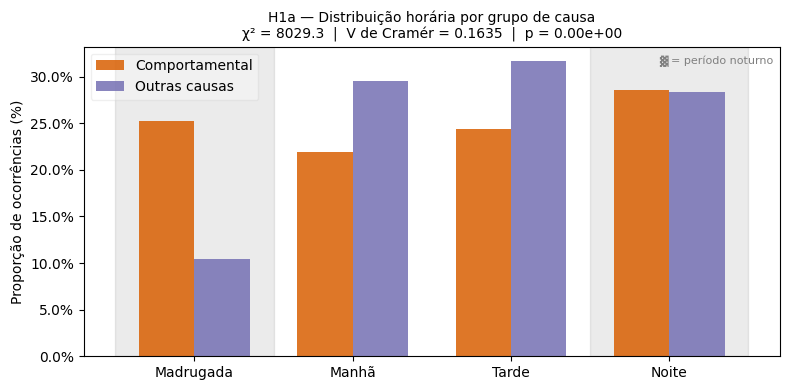

In [5]:
HOUR_ORDER = ['Madrugada', 'Manhã', 'Tarde', 'Noite']

rate_table = result.h1a.rate_table[HOUR_ORDER]

fig, ax = plt.subplots(figsize=(8, 4))

x = np.arange(len(HOUR_ORDER))
width = 0.35

bars_beh = ax.bar(
    x - width / 2,
    rate_table.loc["comportamental"] * 100,
    width,
    label='Comportamental',
    color='#d95f02',
    alpha=0.85,
)
bars_oth = ax.bar(
    x + width / 2,
    rate_table.loc['outras_causas'] * 100,
    width,
    label='Outras causas',
    color='#7570b3',
    alpha=0.85,
)

night_indices = [HOUR_ORDER.index(p) for p in NIGHT_PERIODS if p in HOUR_ORDER]
for idx in night_indices:
    ax.axvspan(idx - 0.5, idx + 0.5, alpha=0.08, color='black', zorder=0)

ax.set_xticks(x)
ax.set_xticklabels(HOUR_ORDER)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylabel('Proporção de ocorrências (%)')
ax.set_title(
    f'H1a — Distribuição horária por grupo de causa\n'
    f'χ² = {result.h1a.chi2:.1f}  |  V de Cramér = {result.h1a.cramers_v:.4f}  '
    f'|  p = {result.h1a.p_value:.2e}',
    fontsize=10,
)
ax.legend(framealpha=0.3)

ax.text(
    0.99, 0.97, '▓ = período noturno',
    transform=ax.transAxes, ha='right', va='top',
    fontsize=8, color='gray'
)

fig.tight_layout()
#plt.savefig('docs/figures/h1a_distribuicao_horaria.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. H1b — OR de fatalidade por grupo de causa e período

In [6]:
# Tabela comparativa dos ORs
h1b = result.h1b

or_summary = pd.DataFrame([
    {
        'Período': 'Geral',
        'OR': h1b.or_overall.odds_ratio,
        'IC Inf': h1b.or_overall.ci_lower,
        'IC Sup': h1b.or_overall.ci_upper,
        'p': h1b.or_overall.p_value,
        'n': h1b.or_overall.n,
        'Significativo': h1b.or_overall.significant,
    },
    {
        'Período': 'Noturno (Madrugada + Noite)',
        'OR': h1b.or_nocturnal.odds_ratio,
        'IC Inf': h1b.or_nocturnal.ci_lower,
        'IC Sup': h1b.or_nocturnal.ci_upper,
        'p': h1b.or_nocturnal.p_value,
        'n': h1b.or_nocturnal.n,
        'Significativo': h1b.or_nocturnal.significant,
    },
    {
        'Período': 'Diurno (Manhã + Tarde)',
        'OR': h1b.or_diurnal.odds_ratio,
        'IC Inf': h1b.or_diurnal.ci_lower,
        'IC Sup': h1b.or_diurnal.ci_upper,
        'p': h1b.or_diurnal.p_value,
        'n': h1b.or_diurnal.n,
        'Significativo': h1b.or_diurnal.significant,
    },
])

display(or_summary.set_index('Período').style.format({
    'OR': '{:.3f}', 'IC Inf': '{:.3f}', 'IC Sup': '{:.3f}', 'p': '{:.2e}'
}))

,OR,IC Inf,IC Sup,p,n,Significativo
Período,,,,,,
Geral,0.949,0.912,0.987,9.42e-03,300086,True
Noturno (Madrugada + Noite),0.662,0.629,0.698,7.11e-54,123165,True
Diurno (Manhã + Tarde),1.280,1.205,1.359,7.12e-16,176921,True


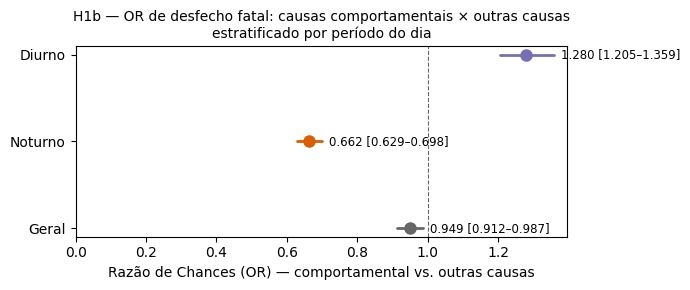

In [7]:
# Forest plot dos ORs por período
fig, ax = plt.subplots(figsize=(7, 3))

periods = ['Geral', 'Noturno', 'Diurno']
or_vals  = [h1b.or_overall.odds_ratio, h1b.or_nocturnal.odds_ratio, h1b.or_diurnal.odds_ratio]
ci_lo    = [h1b.or_overall.ci_lower,   h1b.or_nocturnal.ci_lower,   h1b.or_diurnal.ci_lower]
ci_hi    = [h1b.or_overall.ci_upper,   h1b.or_nocturnal.ci_upper,   h1b.or_diurnal.ci_upper]
colors   = ['#666666', '#d95f02', '#7570b3']

y_pos = np.arange(len(periods))

for i, (y, or_v, lo, hi, c) in enumerate(zip(y_pos, or_vals, ci_lo, ci_hi, colors)):
    ax.plot([lo, hi], [y, y], color=c, linewidth=2, solid_capstyle='round')
    ax.plot(or_v, y, 'o', color=c, markersize=8, zorder=5)
    ax.text(hi + 0.02, y, f'{or_v:.3f} [{lo:.3f}–{hi:.3f}]', va='center', fontsize=8.5)

ax.axvline(1.0, color='black', linewidth=0.8, linestyle='--', alpha=0.6)
ax.set_yticks(y_pos)
ax.set_yticklabels(periods)
ax.set_xlabel('Razão de Chances (OR) — comportamental vs. outras causas')
ax.set_title(
    'H1b — OR de desfecho fatal: causas comportamentais × outras causas\n'
    'estratificado por período do dia',
    fontsize=10,
)
ax.set_xlim(left=0)

fig.tight_layout()
#plt.savefig('docs/figures/h1b_forest_plot.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Heatmap de taxa de fatalidade — causa × horário

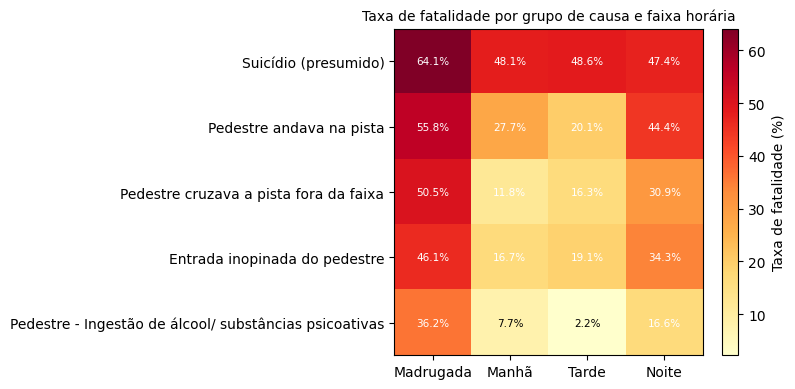

In [12]:
# Taxa de fatalidade por grupo de causa e faixa horária
fatal_rates = (
    df.assign(is_fatal=df['classificacao_acidente'] == 'Com Vítimas Fatais')
    .groupby(['causa_acidente', 'horario'])['is_fatal']
    .mean()
    .unstack('horario')[HOUR_ORDER]
    .sort_values('Madrugada', ascending=False)
    .head()
)

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(fatal_rates.values * 100, aspect='auto', cmap='YlOrRd')

ax.set_xticks(range(len(HOUR_ORDER)))
ax.set_xticklabels(HOUR_ORDER)
ax.set_yticks(range(len(fatal_rates)))
ax.set_yticklabels(fatal_rates.index)

# Anotações
for i in range(len(fatal_rates)):
    for j in range(len(HOUR_ORDER)):
        val = fatal_rates.values[i, j] * 100
        color = 'white' if val > 10 else 'black'
        ax.text(j, i, f'{val:.1f}%', ha='center', va='center',
                fontsize=7.5, color=color)

plt.colorbar(im, ax=ax, label='Taxa de fatalidade (%)')
ax.set_title('Taxa de fatalidade por grupo de causa e faixa horária', fontsize=10)
fig.tight_layout()
#plt.savefig('docs/figures/h1_heatmap_causa_horario.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
(df.assign(is_fatal=df['classificacao_acidente'] == 'Com Vítimas Fatais')
   .groupby('causa_acidente')['is_fatal']
   .agg(['mean', 'sum', 'count'])
   .sort_values('sum', ascending=False)
   .head(10))

,mean,sum,count
causa_acidente,,,
Transitar na contramão,0.292869,2953,10083
Ausência de reação do condutor,0.064327,2737,42548
Reação tardia ou ineficiente do condutor,0.052111,2254,43254
Velocidade Incompatível,0.087771,1658,18890
Acessar a via sem observar a presença dos outros veículos,0.055593,1563,28115
Ultrapassagem Indevida,0.167472,1213,7243
Pedestre andava na pista,0.419003,1151,2747
Entrada inopinada do pedestre,0.291156,856,2940
Manobra de mudança de faixa,0.048039,811,16882


In [13]:
fatal_rates

horario,Madrugada,Manhã,Tarde,Noite
causa_acidente,,,,
Suicídio (presumido),0.641026,0.481132,0.486301,0.474026
Pedestre andava na pista,0.558182,0.277228,0.200599,0.444231
Pedestre cruzava a pista fora da faixa,0.505208,0.118126,0.162791,0.308528
Entrada inopinada do pedestre,0.461318,0.166667,0.190828,0.343102
Pedestre - Ingestão de álcool/ substâncias psicoativas,0.361702,0.076923,0.022222,0.165957


## 5. Resultado final

In [9]:
print('=' * 60)
print(result.summary)
print('=' * 60)
print(f'\nH1 confirmada: {result.confirmed}')
print(f'  H1a (concentração noturna): {result.h1a.confirmed}')
print(f'  H1b (maior gravidade noturna): {result.h1b.confirmed}')

H1 — PARCIALMENTE CONFIRMADA

Causas comportamentais: 'Condutor Dormindo', 'Velocidade Incompatível', 'Ingestão de álcool pelo condutor', 'Ingestão de substâncias psicoativas pelo condutor'
(44,867 registros; 15.0% da base).

H1a (concentração noturna):
  χ² = 8029.3  |  V de Cramér = 0.1635  |  p = 0.00e+00
  ✓ Confirmada: causas comportamentais são proporcionalmente mais frequentes em Madrugada e Noite.

H1b (maior gravidade noturna):
  OR noturno  = 0.662  [IC 95%: 0.629–0.698]  ✓
  OR diurno   = 1.280  [IC 95%: 1.205–1.359]  ✓
  ✗ Não confirmada: OR noturno <= OR diurno.

H1 confirmada: False
  H1a (concentração noturna): True
  H1b (maior gravidade noturna): False
